In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        DATA_DIR / 'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from itertools import compress
from scipy import stats
import random
from bisect import bisect
import warnings
import xgboost as xgb
import time

In [69]:
positive = pd.read_csv(DATA_DIR / 'simulated' / 'positive_heatmap.csv').reset_index(drop=True)
negative = pd.read_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv').reset_index(drop=True)
pearson_pos = pd.read_csv(DATA_DIR / 'simulated' / 'positive_pearson.csv').reset_index(drop=True)
pearson_neg = pd.read_csv(DATA_DIR / 'simulated' / 'negative_pearson.csv').reset_index(drop=True)
spearman_pos = pd.read_csv(DATA_DIR / 'simulated' / 'positive_spearman.csv').reset_index(drop=True)
spearman_neg = pd.read_csv(DATA_DIR / 'simulated' / 'negative_spearman.csv').reset_index(drop=True)
mi_pos = pd.read_csv(DATA_DIR / 'simulated' / 'positive_mi.csv').reset_index(drop=True)
mi_neg = pd.read_csv(DATA_DIR / 'simulated' / 'negative_mi.csv').reset_index(drop=True)
bicor_pos = pd.read_csv(DATA_DIR / 'simulated' / 'positive_bicor.csv').reset_index(drop=True)
bicor_neg = pd.read_csv(DATA_DIR / 'simulated' / 'negative_bicor.csv').reset_index(drop=True)



In [70]:
data_dict = {}
data_dict['PDM'] = (positive, negative)
data_dict['Pearson'] = (pearson_pos, pearson_neg)
data_dict['Spearman'] = (spearman_pos, spearman_neg)
data_dict['MutualInfo'] = (mi_pos, mi_neg)
data_dict['Bicor'] = (bicor_pos, bicor_neg)

In [71]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [72]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [73]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


Running PDM - SVR
Running PDM - XGB
Running PDM - GBR
Running PDM - DTR
Running PDM - LR
Running Pearson - SVR
Running Pearson - XGB
Running Pearson - GBR
Running Pearson - DTR
Running Pearson - LR
Running Spearman - SVR
Running Spearman - XGB
Running Spearman - GBR
Running Spearman - DTR
Running Spearman - LR
Running MutualInfo - SVR
Running MutualInfo - XGB
Running MutualInfo - GBR
Running MutualInfo - DTR
Running MutualInfo - LR
Running Bicor - SVR
Running Bicor - XGB
Running Bicor - GBR
Running Bicor - DTR
Running Bicor - LR


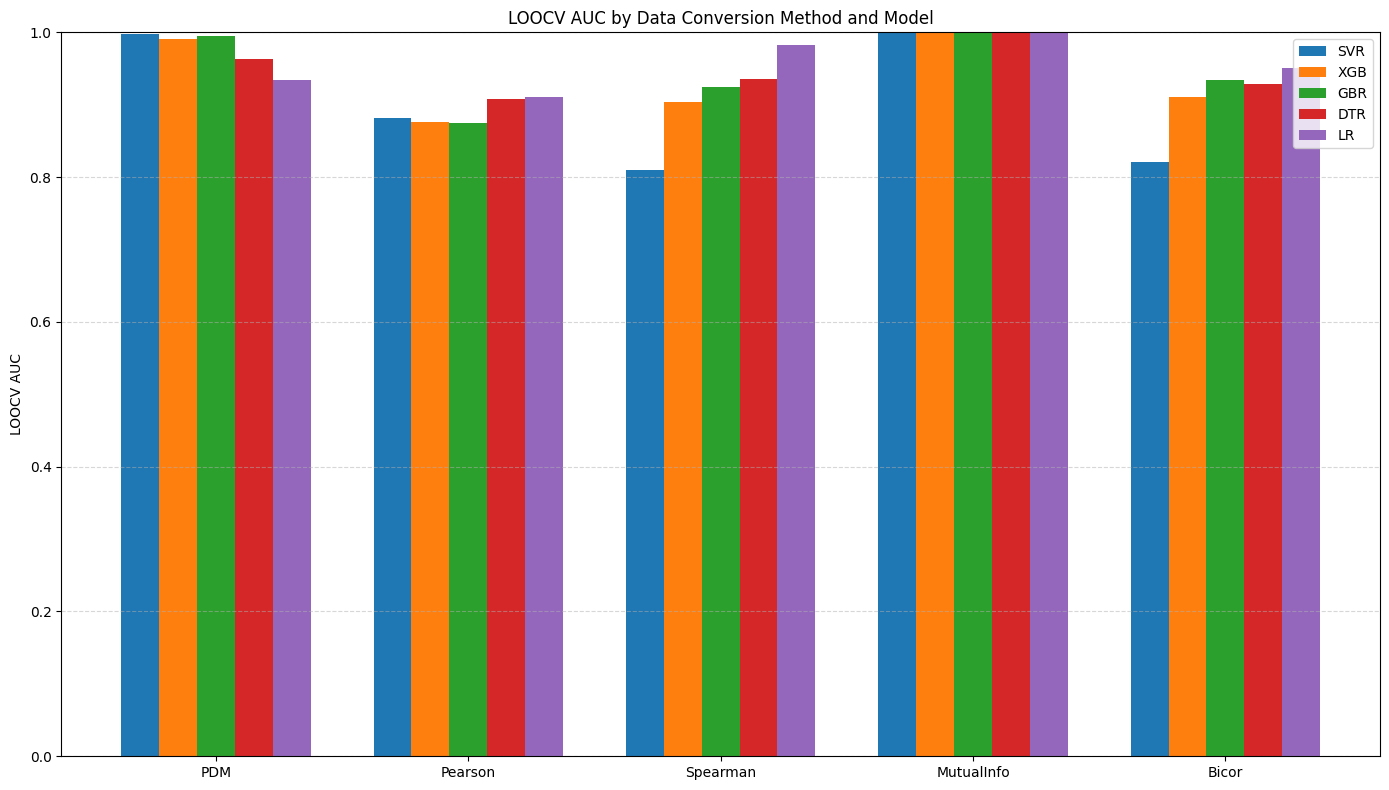

array([[0.99784511, 0.99049648, 0.99508625, 0.96297085, 0.93360882],
       [0.88152242, 0.87546823, 0.87474476, 0.90788061, 0.91067397],
       [0.80935453, 0.90374631, 0.92479626, 0.93490975, 0.98230788],
       [0.9999755 , 0.999999  , 0.9999295 , 0.99968002, 0.999998  ],
       [0.82037648, 0.91091195, 0.93410179, 0.92843108, 0.95131993]])

In [74]:
LOOCV_grouped_plot(data_dict, 5)

In [75]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


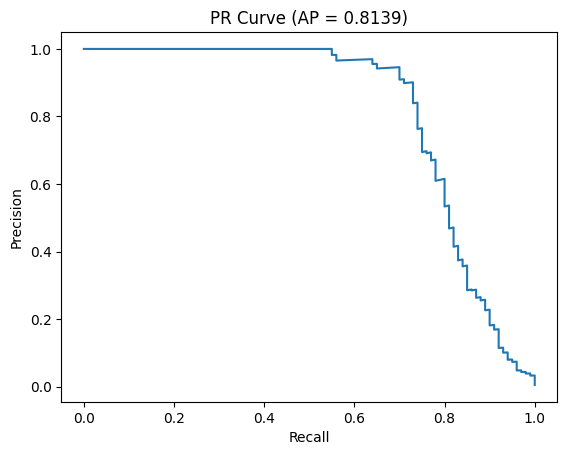

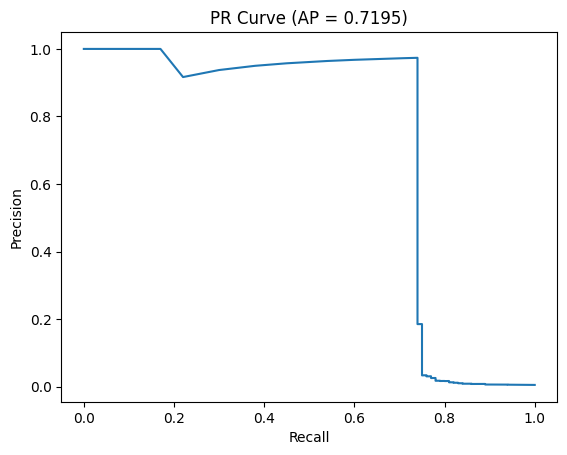

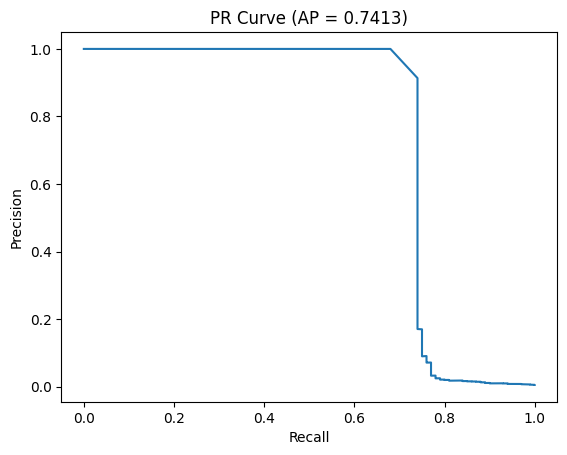

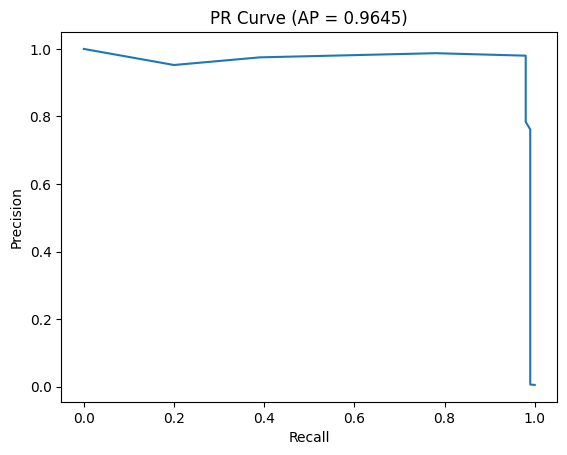

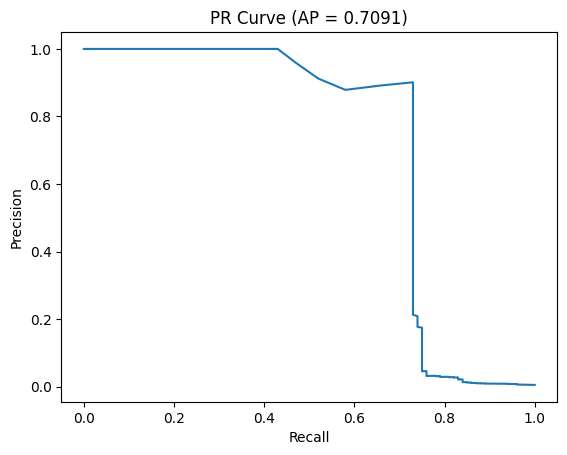

In [76]:
curr = time.time()
area, x, y = KFold_PR(positive.to_numpy(), negative.to_numpy(), 25, 
      model='XGB', ks_test=True, features_left=48, graph=True)
hm_time = time.time()-curr

curr = time.time()
p_area, p_x, p_y = KFold_PR(pearson_pos.to_numpy(), pearson_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, graph=True)
p_time = time.time()-curr

curr = time.time()
s_area, s_x, s_y = KFold_PR(spearman_pos.to_numpy(), spearman_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, graph=True)
s_time = time.time()-curr

curr = time.time()
mi_area, mi_x, mi_y = KFold_PR(mi_pos.to_numpy(), mi_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, graph=True)
mi_time = time.time()-curr

curr = time.time()
b_area, b_x, b_y = KFold_PR(bicor_pos.to_numpy(), bicor_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, graph=True)
b_time = time.time()-curr

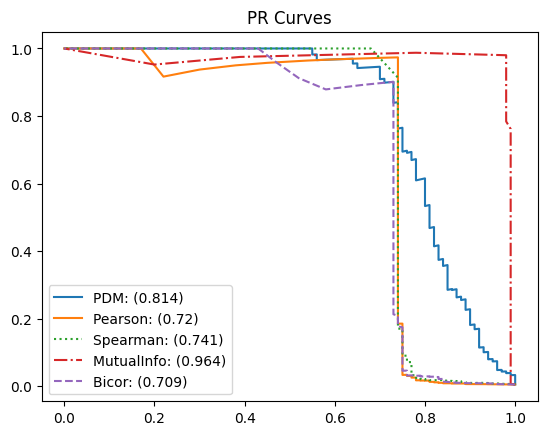

In [77]:
plt.plot(x, y, label = "PDM: ("+str(round(area, 3))+")")
plt.plot(p_x, p_y, label = "Pearson: ("+str(round(p_area, 3))+")", linestyle="-")
plt.plot(s_x, s_y, label = "Spearman: ("+str(round(s_area, 3))+")", linestyle=":")
plt.plot(mi_x, mi_y, label = "MutualInfo: ("+str(round(mi_area, 3))+")", linestyle="-.")
plt.plot(b_x, b_y, label = "Bicor: ("+str(round(b_area, 3))+")", linestyle="--")
plt.title("PR Curves")
plt.legend()
plt.show()

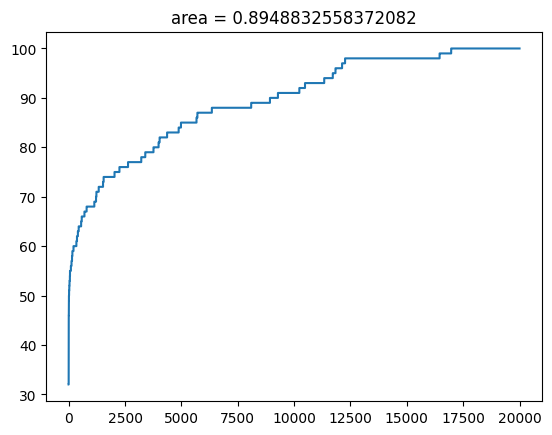

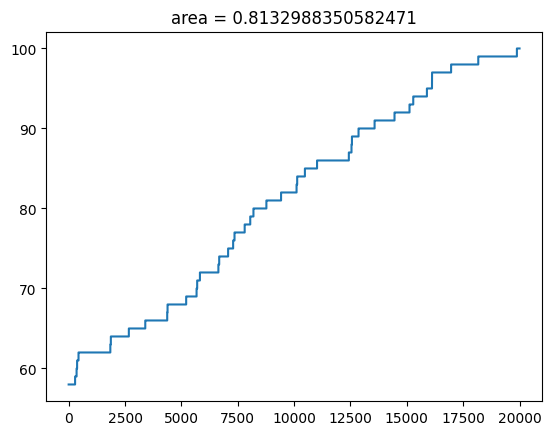

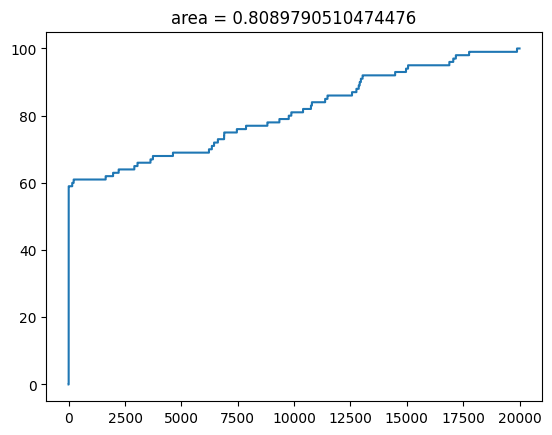

In [20]:
curr = time.time()
area, x, y = LOOCV(positive.to_numpy(), negative.to_numpy(), 25, 
      model='XGB', ks_test=True, features_left=48, graph=True, equation=True)
hm_time = time.time()-curr

curr = time.time()
p_area, p_x, p_y = LOOCV(pearson_pos.to_numpy(), pearson_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, features_left=None, graph=True, equation=True)
p_time = time.time()-curr

curr = time.time()
s_area, s_x, s_y = LOOCV(spearman_pos.to_numpy(), spearman_neg.to_numpy(), 25, 
      model='XGB', ks_test=False, features_left=None, graph=True, equation=True)
s_time = time.time()-curr

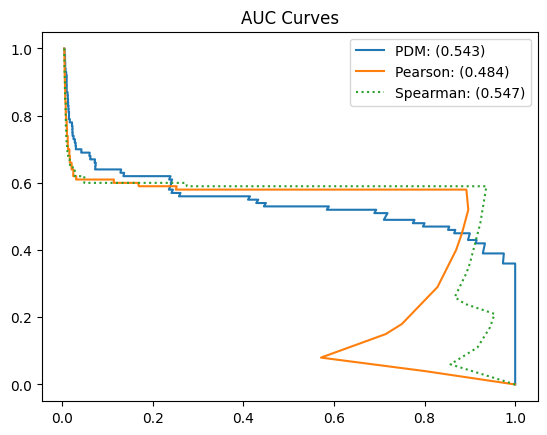

15.191708087921143 19.819572925567627 19.554527044296265


In [44]:
plt.plot(x, y, label = "PDM: ("+str(round(area, 3))+")")
plt.plot(p_x, p_y, label = "Pearson: ("+str(round(p_area, 3))+")", linestyle="-")
plt.plot(s_x, s_y, label = "Spearman: ("+str(round(s_area, 3))+")", linestyle=":")
plt.title("AUC Curves")
plt.legend()
plt.show()
print(hm_time, p_time, s_time)

In [44]:
graphs = [method_area, method_x, method_y, pearson_area, pearson_x, pearson_y, spearman_area, spearman_x, spearman_y,]
pd.Series(graphs).to_csv(r"C:\Users\justi\Coding\Coding_Project\Han Xu\Trimmed data\graphs.csv", index = False)

In [8]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [71]:
feature_arr = [10, 20, 50, 100, 124, 150, 200, 250, 300, 349]
areas = area_table(positive.iloc[:,1:-1].values, negative.iloc[:,1:-1].values, 20, 
                       model='GBR', feat_arr=feature_arr)

10
20
50
100
124
150
200
250
300
349
